# 6.4 - EDA orientado a riesgo (sección 6.4)

Caso 15 - Caja Rural 360 | Microcredito rural para independientes

Evidencia para 'reports/04edariesgo.md'. Genera las tablas en 'reports/tables/' y las figuras en 'reports/figures/' (fig11 a fig18).


In [1]:
import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import eda

pd.set_option("display.max_columns", 50)

df = pd.read_csv("../data/processed/pd_population.csv", parse_dates=["observation_date"])
pop = eda.to_modelable(df)  # outcomeavailable_flag == 1
global_rate = eda.overall_bad_rate(pop)
print(f"Total: {len(df)} | N modelable PD: {len(pop)} | Bad rate global: {global_rate:.2%}")

Total: 5783 | N modelable PD: 5783 | Bad rate global: 11.60%


# 1. Bad rate global y composición de cartera

In [2]:
summary = pd.DataFrame({
    "poblacion": ["Total base", "Rechazados (sin outcome)", "Modelable PD (outcome=1)", "Default en modelable"],
    "n": [len(df), (df.outcome_available_flag == 0).sum(), len(pop), pop.default_12m_flag.sum()]
})
summary["pct_sobre_total"] = summary["n"] / len(df)
summary.to_csv("../reports/tables/eda_00_resumen_poblacion.csv", index=False)
summary

,poblacion,n,pct_sobre_total
0,Total base,5783,1.00000
1,Rechazados (sin outcome),0,0.00000
2,Modelable PD (outcome=1),5783,1.00000
3,Default en modelable,671,0.11603


,bin,bad_rate,n,bin_order
0,"(378.999, 577.0]",0.284698,562,0
1,"(577.0, 611.0]",0.188482,573,1
2,"(611.0, 633.0]",0.158470,549,2
3,"(633.0, 654.0]",0.122807,570,3
4,"(654.0, 671.0]",0.100000,550,4
5,"(671.0, 690.0]",0.103387,561,5
6,"(690.0, 709.0]",0.071813,557,6
7,"(709.0, 732.0]",0.075812,554,7
8,"(732.0, 765.0]",0.049822,562,8
9,"(765.0, 850.0]",0.018116,552,9


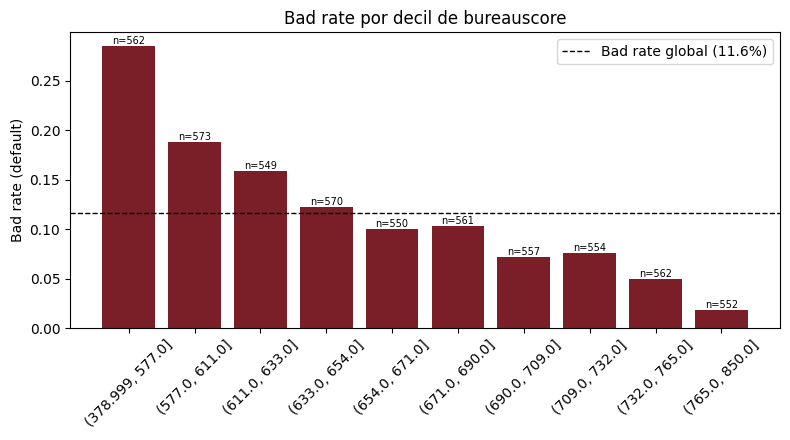

In [3]:
tab_bureau = eda.bad_rate_by_decile(pop, "bureau_score", q=10)
tab_bureau.to_csv("../reports/tables/eda_01_badrate_bureau_score.csv", index=False)
fig = eda.plot_bad_rate_bars(tab_bureau, "bin", title="Bad rate por decil de bureauscore", global_rate=global_rate)
fig.savefig("../reports/figures/fig11badratebureau_score.png", dpi=150)
tab_bureau

# 3. Bad rate por DTI (relacion no lineal tipo 'J') - Figura 12

,bin,bad_rate,n,bin_order
0,"(0.0013999999999999998, 0.0881]",0.094991,579,0
1,"(0.0881, 0.135]",0.089810,579,1
2,"(0.135, 0.179]",0.103627,579,2
3,"(0.179, 0.222]",0.095321,577,3
4,"(0.222, 0.263]",0.089810,579,4
5,"(0.263, 0.311]",0.103806,578,5
6,"(0.311, 0.358]",0.119377,578,6
7,"(0.358, 0.421]",0.117851,577,7
8,"(0.421, 0.506]",0.181661,578,8
9,"(0.506, 0.859]",0.164076,579,9


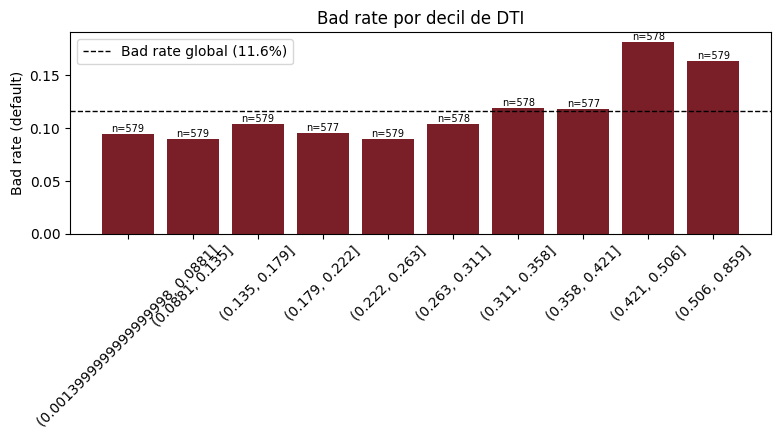

In [4]:
tab_dti = eda.bad_rate_by_decile(pop, "dti", q=10)
tab_dti.to_csv("../reports/tables/eda_02_bad_rate_dti.csv", index=False)
fig = eda.plot_bad_rate_bars(tab_dti, "bin", title="Bad rate por decil de DTI", global_rate=global_rate)
fig.savefig("../reports/figures/fig12_badrate_dti.png", dpi=150)
tab_dti

# 4. Interaccion bureau_score x DTI (superaditividad) - Figura 13

,bureau_score,dti,bad_rate,n
0,alto (>=611),alto (>=0.42),0.294776,268
1,alto (>=611),bajo (<0.42),0.192493,1039
2,bajo (<611),alto (>=0.42),0.135802,891
3,bajo (<611),bajo (<0.42),0.075593,3585


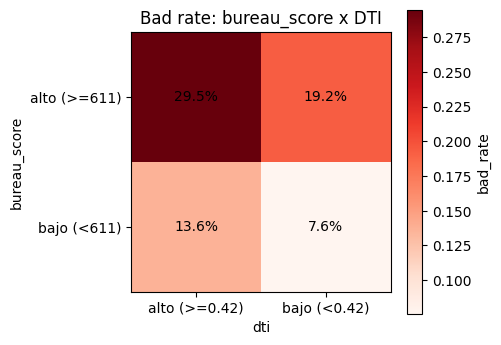

In [5]:
inter = eda.two_way_interaction(pop, "bureau_score", "dti", thr_a=611, thr_b=0.421,
    label_a=("alto (>=611)", "bajo (<611)"),
    label_b=("bajo (<0.42)", "alto (>=0.42)"))
inter.to_csv("../reports/tables/eda_03_interaccion_bureau_dti.csv", index=False)
fig = eda.plot_heatmap_2x2(inter, "bureau_score", "dti", title="Bad rate: bureau_score x DTI")
fig.savefig("../reports/figures/fig13_interaccion_bureau_dti.png", dpi=150)
inter

# 5. Cosechas (vintages) trimestrales - Figura 14

,vintage,bad_rate,n
0,2021Q1,0.094637,317
1,2021Q2,0.085809,303
2,2021Q3,0.096220,291
3,2021Q4,0.066667,270
4,2022Q1,0.083032,277
5,2022Q2,0.101307,306
6,2022Q3,0.118881,286
7,2022Q4,0.083032,277
8,2023Q1,0.108303,277
9,2023Q2,0.149466,281


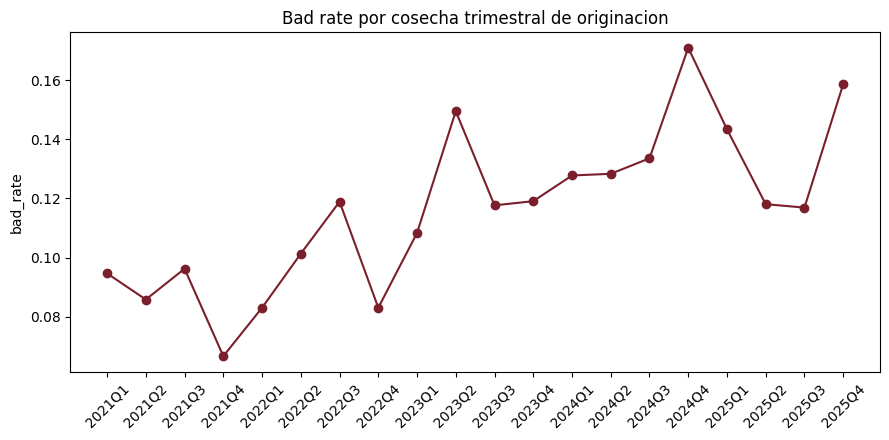

In [6]:
vint = eda.vintage_bad_rate(pop, freq="Q")
vint.to_csv("../reports/tables/eda_04_vintage_bad_rate.csv", index=False)
fig = eda.plot_trend_line(vint, "vintage", "bad_rate", title="Bad rate por cosecha trimestral de originacion")
fig.savefig("../reports/figures/fig14_vintage_badrate.png", dpi=150)
vint

# 6. Tasa de aprobacion vs bad rate por cosecha (politica vs deterioro) - Figura 15

,vintage,approval_rate,n
0,2021Q1,1.0,317
1,2021Q2,1.0,303
2,2021Q3,1.0,291
3,2021Q4,1.0,270
4,2022Q1,1.0,277
5,2022Q2,1.0,306
6,2022Q3,1.0,286
7,2022Q4,1.0,277
8,2023Q1,1.0,277
9,2023Q2,1.0,281


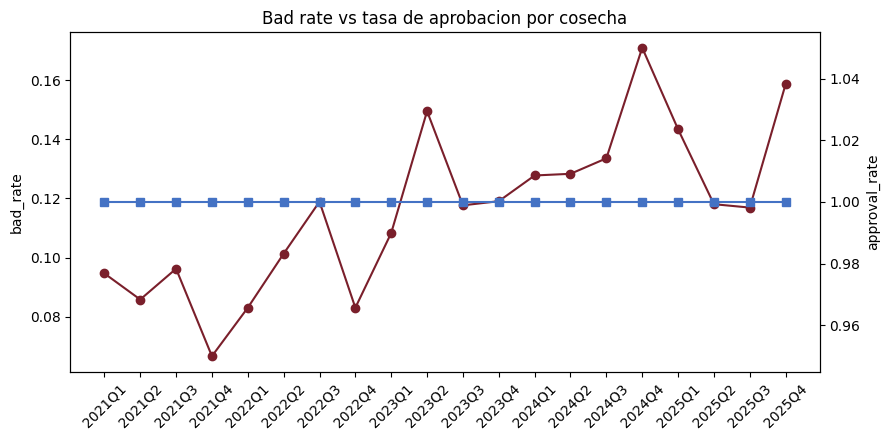

In [8]:
appr = eda.approval_rate_trend(df, freq="Q")
appr.to_csv("../reports/tables/eda_05_approval_trend.csv", index=False)
fig = eda.plot_trend_line(vint, "vintage", "bad_rate", title="Bad rate vs tasa de aprobacion por cosecha",
                          secondary=appr,secondary_y_col="approval_rate", secondary_label="approval_rate")
fig.savefig("../reports/figures/fig15_approvalvs_badrate.png", dpi=150)
appr

# 7. Sesgo de seleccion: bureau_score en aprobados vs rechazados

In [10]:
sel = eda.selection_bias_check(df, "bureau_score")
sel.to_csv("../reports/tables/eda_06_selection_bias_bureau.csv")
sel

,count,mean,std,min,50%,max
approved_flag,,,,,,
1,5590.0,670.766726,73.132531,379.0,671.0,850.0


# 8. Bad rate por segmentos categoricos: region, canal, tipo de empleo, cliente nuevo - Figura 16

In [13]:
for col in ["region", "channel", "employment_type", "new_customer_flag"]:
    t = eda.bad_rate_by_category(pop, col)
    t.to_csv(f"../reports/tables/eda_07_badrate_{col}.csv", index=False)
    print(col)
    display(t)

region


,region,bad_rate,n,share,flag_low_n
0,Lima,0.126566,2394,0.413972,False
1,Norte,0.121019,1099,0.190040,False
2,Centro,0.115861,889,0.153726,False
3,Oriente,0.094718,549,0.094933,False
4,Sur,0.093897,852,0.147328,False


channel


,channel,bad_rate,n,share,flag_low_n
0,agencia,0.120800,1250,0.216151,False
1,web,0.120099,2015,0.348435,False
2,alianza,0.119349,553,0.095625,False
3,app,0.107888,1965,0.339789,False


employment_type


,employment_type,bad_rate,n,share,flag_low_n
0,empresa,0.125000,416,0.071935,False
1,independiente,0.119271,1811,0.313159,False
2,dependiente,0.115334,3052,0.527754,False
3,temporal,0.101190,504,0.087152,False


new_customer_flag


,new_customer_flag,bad_rate,n,share,flag_low_n
0,1,0.127386,2567,0.443887,False
1,0,0.106965,3216,0.556113,False


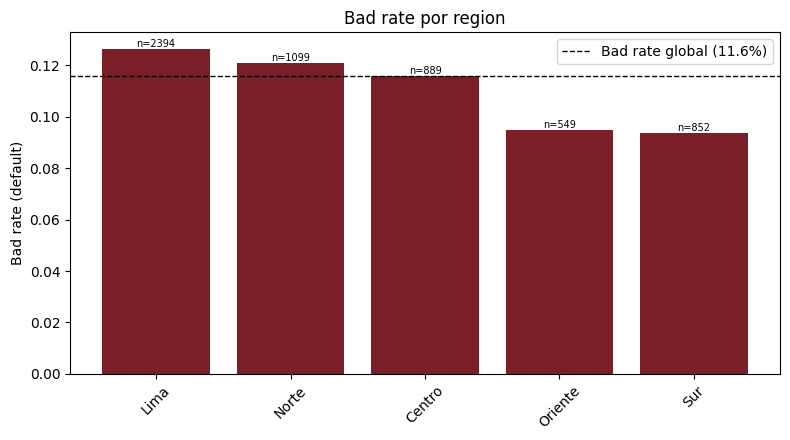

In [17]:
t_region = eda.bad_rate_by_category(pop, "region")
fig = eda.plot_bad_rate_bars(t_region, "region", title="Bad rate por region", global_rate=global_rate)
fig.savefig("../reports/figures/fig16_badrate_region.png", dpi=150)

# 9. Ahorros (savings_balance): relacion protectora y faltantes - Figura 17

,is_missing,bad_rate,n
0,0,0.116545,5337
1,1,0.109865,446


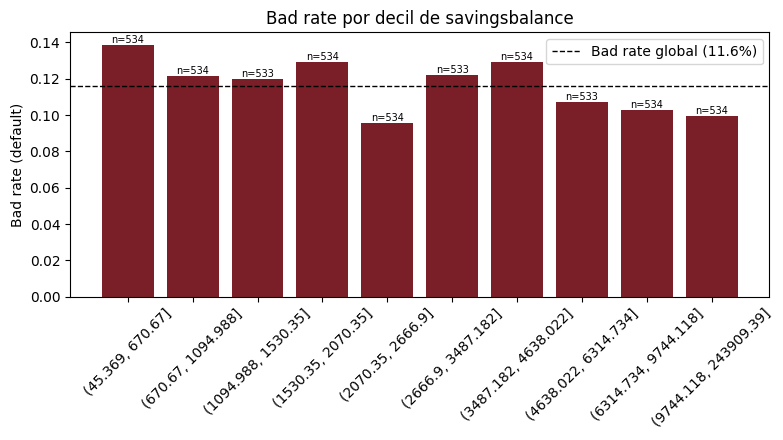

In [20]:
tab_sav = eda.bad_rate_by_decile(pop, "savings_balance", q=10)
tab_sav.to_csv("../reports/tables/eda_08_badrate_savings.csv", index=False)
fig = eda.plot_bad_rate_bars(tab_sav, "bin", title="Bad rate por decil de savingsbalance", global_rate=global_rate)
fig.savefig("../reports/figures/fig17badratesavings.png", dpi=150)

miss_sav = eda.missing_rate_vs_bad_rate(pop, "savings_balance")
miss_sav.to_csv("../reports/tables/eda09missingsavingsvs_badrate.csv", index=False)
miss_sav

# 10. Variables discretas ruidosas: priordelinquencies24m, activeloans, bureauinquiries6m, householddependents

In [24]:
for col in ["prior_delinquencies_24m", "active_loans", "bureau_inquiries_6m", "household_dependents"]:
    t = pop.groupby(col)["default_12m_flag"].agg(bad_rate="mean", n="count").reset_index()
    t.to_csv(f"../reports/tables/eda_10_badrate_{col}.csv", index=False)
    print(col)
    display(t)

prior_delinquencies_24m


,prior_delinquencies_24m,bad_rate,n
0,0,0.108938,3323
1,1,0.124392,1849
2,2,0.137450,502
3,3,0.087912,91
4,4,0.153846,13
5,5,0.000000,5


active_loans


,active_loans,bad_rate,n
0,0,0.130146,753
1,1,0.120733,1582
2,2,0.101834,1581
3,3,0.120202,990
4,4,0.123435,559
5,5,0.103139,223
6,6,0.112500,80
7,7,0.000000,10
8,8,0.333333,3
9,9,0.000000,1


bureau_inquiries_6m


,bureau_inquiries_6m,bad_rate,n
0,0,0.098958,960
1,1,0.127085,1739
2,2,0.110313,1532
3,3,0.119099,932
4,4,0.127660,423
5,5,0.125874,143
6,6,0.054054,37
7,7,0.066667,15
8,8,0.000000,1
9,9,0.000000,1


household_dependents


,household_dependents,bad_rate,n
0,0,0.107644,641
1,1,0.122769,1401
2,2,0.114798,1507
3,3,0.111395,1176
4,4,0.100787,635
5,5,0.146853,286
6,6,0.154639,97
7,7,0.142857,35
8,8,0.000000,5


# 11. Variables 100% NA para este producto (documentacion de alcance) - Figura 18

In [25]:
na_cols = ["credit_limit", "balance_at_observation", "utilization_at_observation",
           "undrawn_amount_at_observation", "ccf_observed", "collateral_value", "ltv"]
na_check = df[na_cols].isna().mean().reset_index()
na_check.columns = ["variable", "pct_na"]
na_check.to_csv("../reports/tables/eda_11_variables_no_aplican_producto.csv", index=False)
na_check

,variable,pct_na
0,credit_limit,1.0
1,balance_at_observation,1.0
2,utilization_at_observation,1.0
3,undrawn_amount_at_observation,1.0
4,ccf_observed,1.0
5,collateral_value,1.0
6,ltv,1.0


# 12. Guardado consolidado de hallazgos
Ver reports/04edariesgo.md para la interpretacion y el impacto en politica/modelo de cada hallazgo.
